<a href="https://colab.research.google.com/github/anandkumarvt/Final_assignment_RNN/blob/main/final_assignment_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
!nvidia-smi

# Install dependencies (optional; TF is usually pre-installed)
!pip install tensorflow tensorflow-datasets matplotlib

Tue Nov 18 23:38:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv3D, Input
import tensorflow_datasets as tfds

In [ ]:
# ===== 2. Load Moving MNIST dataset =====
ds = tfds.load('moving_mnist', split='test', as_supervised=False)
ds = ds.take(2000)  # small subset for faster training

frames = []
for example in tfds.as_numpy(ds):
    frames.append(example['image_sequence'])
frames = np.stack(frames)  # shape: (num_samples, 20, 64, 64, 1)
print("Dataset shape:", frames.shape)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/moving_mnist/incomplete.BOQC91_1.0.0/moving_mnist-test.tfrecord*...:   0%|…

Dataset moving_mnist downloaded and prepared to /root/tensorflow_datasets/moving_mnist/1.0.0. Subsequent calls will reuse this data.
Dataset shape: (2000, 20, 64, 64, 1)


In [ ]:
# ===== 3. Prepare Input and Target =====
X = frames[:, :10, :, :, :].astype('float32') / 255.0  # first 10 frames as input
y = frames[:, 10:, :, :, :].astype('float32') / 255.0  # next 10 frames as target
print("Input shape:", X.shape, "Target shape:", y.shape)

Input shape: (2000, 10, 64, 64, 1) Target shape: (2000, 10, 64, 64, 1)


In [ ]:
# ===== 4. Explicit Train / Validation / Test Split =====
num_samples = X.shape[0]
train_size = int(num_samples * 0.7)    # 70% for training
val_size = int(num_samples * 0.15)     # 15% for validation
test_size = num_samples - train_size - val_size  # remaining 15% for testing

# Train
X_train = X[:train_size]
y_train = y[:train_size]

# Validation
X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

# Test
X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (1400, 10, 64, 64, 1) Validation: (300, 10, 64, 64, 1) Test: (300, 10, 64, 64, 1)


In [ ]:
# ===== 5. Build ConvLSTM Model =====
input_shape = (10, 64, 64, 1)
model = Sequential([
    Input(shape=input_shape),
    ConvLSTM2D(64, (3,3), activation='relu', padding='same', return_sequences=True),
    BatchNormalization(),
    ConvLSTM2D(64, (3,3), activation='relu', padding='same', return_sequences=True),
    BatchNormalization(),
    Conv3D(1, (3,3,3), activation='sigmoid', padding='same')
])

In [ ]:
# ===== 6. Compile =====
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 10, 64, 64, 64) │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64, 64, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 10, 64, 64, 64) │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64, 64, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 10, 64, 64, 1)  │         1,729 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 447,425 (1.71 MB)

 Trainable params: 447,169 (1.71 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# ===== 7. Train with Explicit Validation =====
history = model.fit(
    X_train, y_train,
    batch_size=4,
    epochs=10,
    validation_data=(X_val, y_val)
)


Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 140ms/step - loss: 0.0637 - val_loss: 0.0404
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 47s 136ms/step - loss: 0.0395 - val_loss: 0.0397
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0387 - val_loss: 0.0391
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0386 - val_loss: 0.0387
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0383 - val_loss: 0.0388
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0382 - val_loss: 0.0389
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0386 - val_loss: 0.0387
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0388 - val_loss: 0.0387
Epoch 9/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0386 - val_loss: 0.0389
Epoch 10/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - loss: 0.0386 - val_loss: 0.0387


In [ ]:
# ===== 8. Evaluate on Test Set =====
test_loss = model.evaluate(X_test, y_test)
print("Test MSE Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 421ms/step - loss: 0.0377
Test MSE Loss: 0.03828377649188042


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


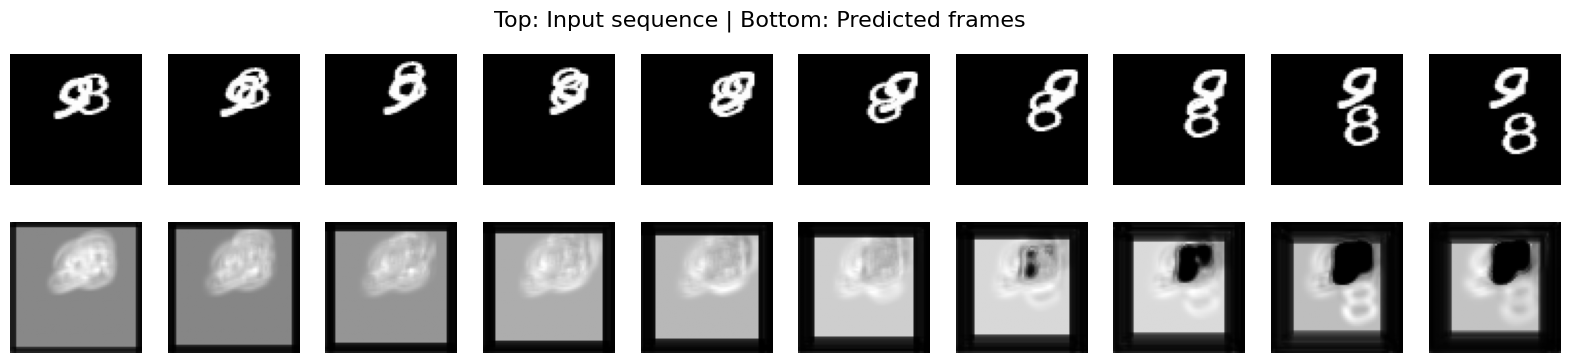

In [ ]:
# ===== 9. Visualize Predictions =====
sample = X_test[0:1]
predicted = model.predict(sample)
plt.figure(figsize=(20,4))
for i in range(10):
    # Original frames
    plt.subplot(2,10,i+1)
    plt.imshow(sample[0,i,:,:,0], cmap='gray')
    plt.axis('off')
    # Predicted frames
    plt.subplot(2,10,10+i+1)
    plt.imshow(predicted[0,i,:,:,0], cmap='gray')
    plt.axis('off')
plt.suptitle("Top: Input sequence | Bottom: Predicted frames", fontsize=16)
plt.show()
